In [1]:
import numpy as np
import torch
import scanpy as sc
import anndata as ad
import os
import pandas as pd
from utils.preprocess import *
from scripts.run_gaga import *

In [2]:
import os
import sys
    
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch
import torchsde
from torchdyn.core import NeuralODE
from tqdm import tqdm

from torchcfm.conditional_flow_matching import *
from torchcfm.models import MLP
from torchcfm.utils import plot_trajectories, torch_wrapper
from simulate.simulate import *
from omegaconf import OmegaConf
from utils.hydra import *
from datasets.process import *
from scripts.run_model import *

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
%reload_ext autoreload
%autoreload 2

In [5]:
dic = {"s": sample_s,
       "s_imbalanced": sample_s_imbalanced,
       "points": sample_points,
       "diamond": sample_diamond,
       "omega": sample_omega,
       "moons": sample_moons,
       "disk": sample_disk,
       "growth": sample_growth,
       "balance": sample_balance,
       }

In [6]:
############################################################

In [7]:
### SETTINGS ###

dataname = "s"
size = 2500
d = 2 #dummy dimension

project = "ffm-ipynb"
adata = process_fake_data(size, d, dic[dataname])
config = load_config()
OmegaConf.set_struct(config, False)
config.pc_dim = d
config.num_classes = adata.obs['cell_type'].nunique()

##################
config.metric = "cfm"

config.classifier_max_epochs = 2
config.metric_max_epochs = 2

# config.classifier.num_layers = 2
# config.classifier.hidden_dim = 256
# config.classifier.spectral_norm = True

In [8]:
############################################################

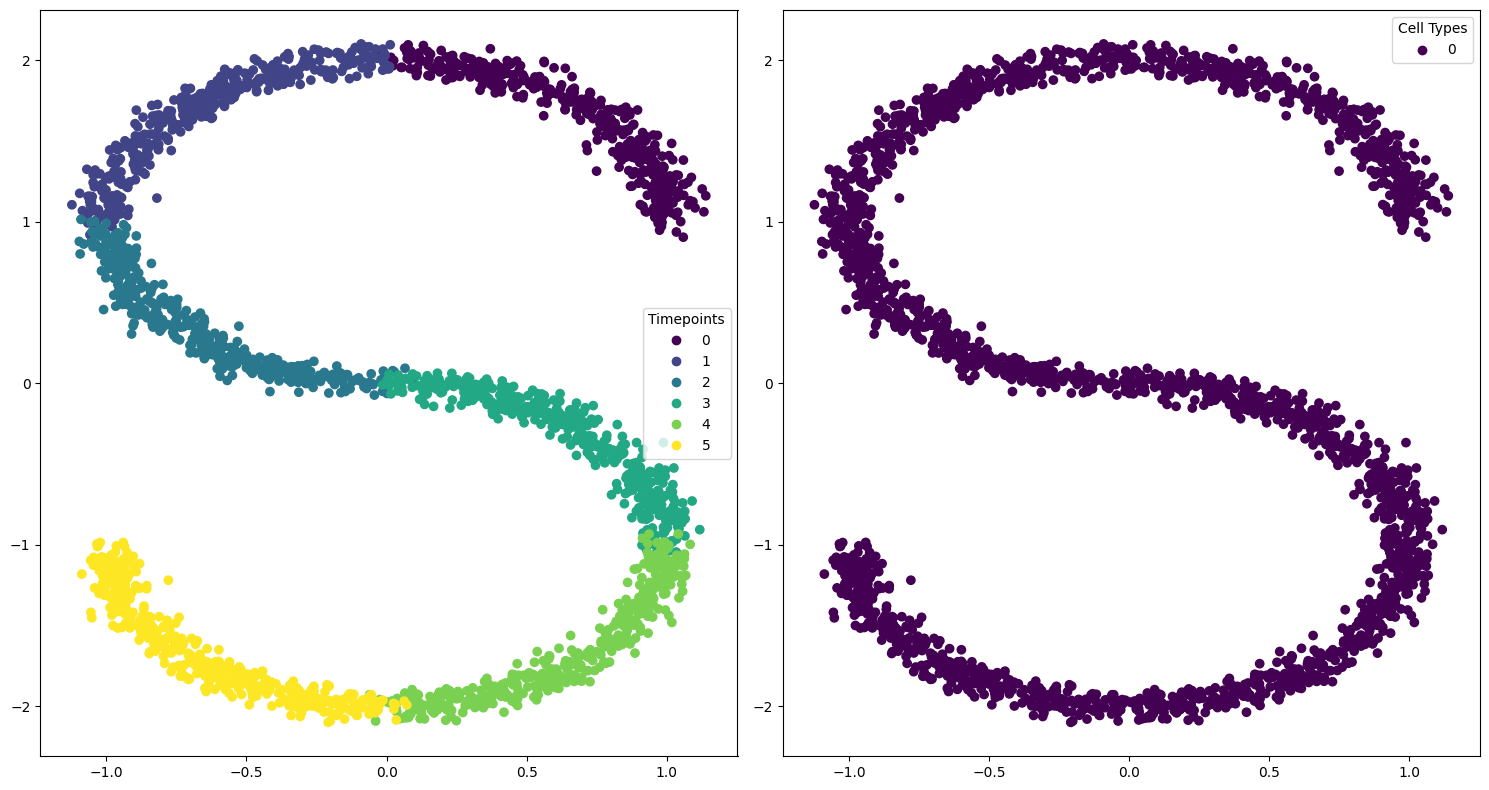

In [9]:
samples = torch.from_numpy(adata.obsm['X_pca']).float()
fig, axs = plt.subplots(1, 2, figsize = (15, 8))
scatter0 = axs[0].scatter(samples[:,0], samples[:, 1], c=adata.obs['timepoint'].astype(int).tolist())
handles, labels = scatter0.legend_elements()
axs[0].legend(handles, labels, title="Timepoints")
scatter1 = axs[1].scatter(samples[:,0], samples[:, 1], c=adata.obs['cell_type_one_hot'].astype(int).tolist())
handles, labels = scatter1.legend_elements()
axs[1].legend(handles, labels, title="Cell Types")

plt.tight_layout()
plt.show()

In [10]:
tree = adata.uns['tree']
timepoints = sorted(adata.obs['timepoint'].unique().tolist())
singleton_dataloader = build_singleton_dataloader(config, adata)
paired_dataloader = build_paired_dataloader(config, adata)
classifier_model, ae_model, disc_model, metric_model, embed_model = run_gaga_model(config,
                                                                             project, 
                                                                             adata, 
                                                                             timepoints, 
                                                                             tree)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4080 SUPER') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


Phase 1: Training autoencoder...


wandb: Currently logged in as: az831 (az831-new-york-genome-center) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name | Type           | Params | Mode 
------------------------------------------------
0 | mlp  | SimpleDenseNet | 43.0 K | train
------------------------------------------------
43.0 K    Trainable params
0         Non-trainable params
43.0 K    Total params
0.172     Total estimated model params size (MB)
15        Modules in train mode
0         Modules in eval mode
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 32. To avoid any miscalculations, use `self.log(..

Phase 2: Training discriminator...


...

Phase 3: Training embed model...


epoch,▁▁▂▂▃▃▃▃▃▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇█▁▂▂▂▃▄▅▅▆▆▆▆▇▇█
train/loss_epoch,█▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/loss_step,▅▅██▆▇▅▃▄▃▃▄▅▆▂▂▂▃▃▄▂▁▂▃▂▃▂▄▃▂▁▂▇▂▄▃▂▂▂▃
train_acc,▁▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▆▆▇▇█
train_loss_epoch,█▅▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▃▃▃▃▃▂▁▁▁
train_loss_step,█▅▇▅▆▅█▇▇▆▆▄▆▆▅▆▆▄▆▆▇▅▆▅▆▆▅▆▇▄▅▄▄▃▄▃▃▅▃▁
trainer/global_step,▁▁▂▂▂▂▃▃▃▄▅▅▅▅▅▆▆▆▆▇▇████▁▂▃▃▃▄▅▅▅▅▆▆▆▆▆
epoch,99
train/loss_epoch,72.86023
train/loss_step,76.41672
train_acc,0.72249


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type           | Params | Mode 
--------------------------------------------------------
0 | embed_net    | SimpleEmbedNet | 159 K  | train
1 | geo_net      | SinNet         | 151 K  | train
2 | metric_model | MetricNetGAGA  | 86.0 K | train
--------------------------------------------------------
310 K     Trainable params
86.0 K    Non-trainable params
396 K     Total params
1.587     Total estimated model params size (MB)
27        Modules in train 

Restored best model from epoch 206 with train_loss_geo_embed=302.844879


epoch,▁▁▁▂▂▂▃▃▄▄▄▄▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇███
train_loss_embed,█▆▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss_geo,▃▃▃▃▁▃▄▄▃▅▄▇▇▆▇▇▅▅▆▆▅█▆▆▅▆▅▅▆▆▇▅▇▆▆▃▃▆▄▆
train_loss_geo_embed,▆▂▂▃▃▁▄▄▄▇▆▅▄▆▃█▅▇▆▅▆▄▅▇▇▃▆▇▃▅▆▅▅▆▄▅▃▆▄▅
trainer/global_step,▁▁▁▁▁▁▂▂▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇██████
epoch,2999
train_loss_embed,0.80809
train_loss_geo,326.28207
train_loss_geo_embed,327.09018
trainer/global_step,2999


In [11]:
#fix the wandb.run.summary bug?
def remove_all_forward_hooks(model):
    for module in model.modules():
        module._forward_hooks.clear()

remove_all_forward_hooks(metric_model)
remove_all_forward_hooks(embed_model)

In [14]:
from torch.utils.data import TensorDataset, Sampler, DataLoader
from datasets.dataset import *

dataset = extract_paired_dataset(adata)
train_dataset = ShufflingDataset(dataset, 20)
train_dataloader = DataLoader(train_dataset, batch_size = 1, shuffle=True)

cpu


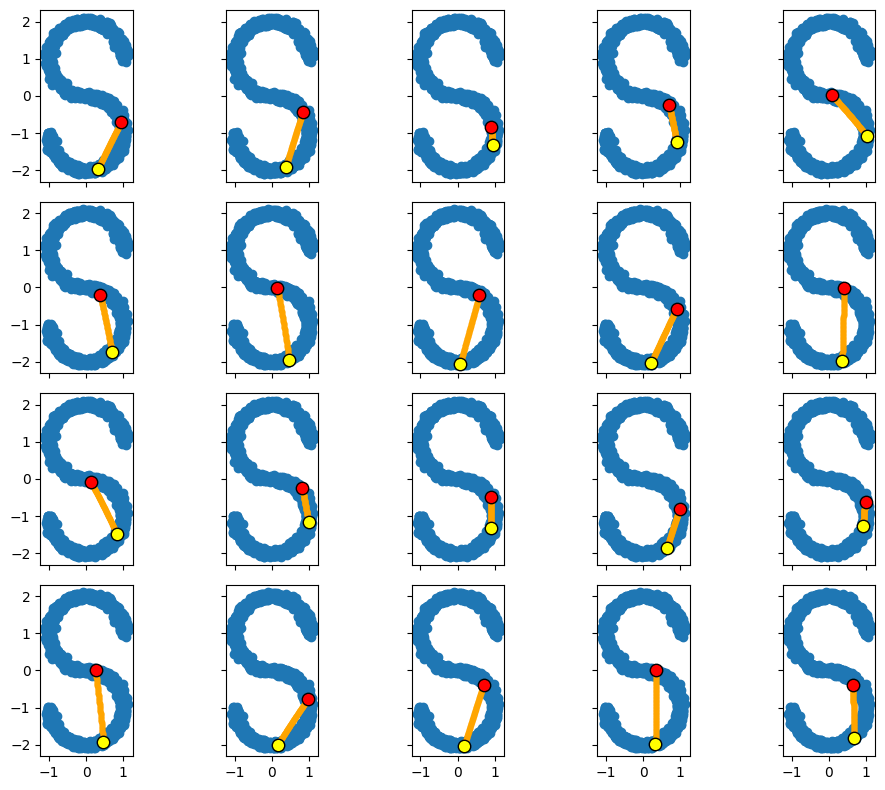

In [15]:
#GEO VALIDATION
for batch in train_dataloader:

    x0, x1, t0, t1 = batch
    print(x0.device)
    
    paths = embed_model.sample_geodesic_path(batch, num_points=200, ot_sample=False)

    break

fig, ax = plt.subplots(4, 5, figsize=(10, 8), sharex=True, sharey=True)

ax = ax.flatten()

for i in range(20):
    traj = paths[:,i]
    ax[i].scatter(samples[:,0], samples[:, 1])
    ax[i].plot(traj[:, 0], traj[:, 1], marker=".", linestyle="-", alpha=0.7, lw=1.5, color='orange')
    ax[i].scatter(traj[0, 0], traj[0, 1], s=80, marker="o", color="red", edgecolor="black", zorder=3)
    ax[i].scatter(traj[-1, 0], traj[-1, 1], s=80, marker="o", color="yellow", edgecolor="black", zorder=3)

    ax[i].set(adjustable='box', aspect='equal')

plt.tight_layout() # Optional: adjusts spacing so labels don't overlap
plt.show()